# Brownian valuation and payoff span

**Reader question.** With two Brownian shocks, which risks can one public claim hedge,
and what remains unspanned?

**Answer in brief.** One risky payoff supplies one direction in shock space. The
government can adjust exposure along that line but cannot remove a fiscal exposure
orthogonal to it. A second independent payoff completes the two-dimensional span. The
extra claim adds a hedge direction, not necessarily another return premium.

The geometry and rank statements are exact. The numbers and arrows below are an
**illustration**, not an accepted model run or a welfare calculation.

## Model and comparison

Hold the Brownian economy and inherited state $(S_0,M_0)$ fixed. Let the two primitive
innovations be productivity and automation. Under the maintained world-pricing
normalization, the first claim's loading is the price-of-risk vector $\lambda$. Rotate
it by ninety degrees to obtain an orthogonal loading $\eta=R\lambda$:

$$
R=\begin{pmatrix}0&-1\\1&0\end{pmatrix},\qquad
\Sigma_1=[\lambda],\qquad
\Sigma_2=[\lambda,\eta].
$$

$\Sigma_1$ has rank one. If $\lambda\ne0$, $\Sigma_2$ has rank two. The second
normalized claim has zero excess return under the maintained world SDF; its role is to
add the missing insurance direction.

## Projection onto the marketed payoff space

The next cell decomposes an illustrative fiscal-exposure vector $\zeta$ into the part
parallel to the traded payoff and the orthogonal residual. The calculation is ordinary
Euclidean projection because the example uses normalized, uncorrelated Brownian
coordinates.

In [1]:
import numpy as np
from IPython.display import Markdown, display

lam = np.array([0.8, 0.6])
rotation = np.array([[0.0, -1.0], [1.0, 0.0]])
eta = rotation @ lam
fiscal_exposure = np.array([-0.2, 1.0])

marketed = (fiscal_exposure @ lam) / (lam @ lam) * lam
unspanned = fiscal_exposure - marketed
sigma_one = lam.reshape(2, 1)
sigma_two = np.column_stack([lam, eta])

lines = [
    "| Object | Value |",
    "|---|---:|",
    f"| rank of one-claim menu | {np.linalg.matrix_rank(sigma_one)} |",
    f"| rank of completed menu | {np.linalg.matrix_rank(sigma_two)} |",
    f"| $\\lambda'\\eta$ | {lam @ eta:.3g} |",
    f"| norm of fiscal exposure | {np.linalg.norm(fiscal_exposure):.3f} |",
    f"| norm marketed by first claim | {np.linalg.norm(marketed):.3f} |",
    f"| norm left unspanned | {np.linalg.norm(unspanned):.3f} |",
    f"| projection identity error | {np.linalg.norm(fiscal_exposure-marketed-unspanned):.2e} |",
    f"| orthogonality error | {abs(unspanned @ lam):.2e} |",
]
display(Markdown("\n".join(lines)))

| Object | Value |
|---|---:|
| rank of one-claim menu | 1 |
| rank of completed menu | 2 |
| $\lambda'\eta$ | 0 |
| norm of fiscal exposure | 1.020 |
| norm marketed by first claim | 0.440 |
| norm left unspanned | 0.920 |
| projection identity error | 0.00e+00 |
| orthogonality error | 5.55e-17 |

## Seeing the missing direction

The first panel shows the one-claim span and the part of fiscal exposure it cannot
reach. The second adds the orthogonal claim. The completed menu spans this two-shock
illustration, but completion of the financial payoff space is not the same as reaching
the first best: distortionary taxation, private ownership, feasibility, and inherited
commitments still matter.

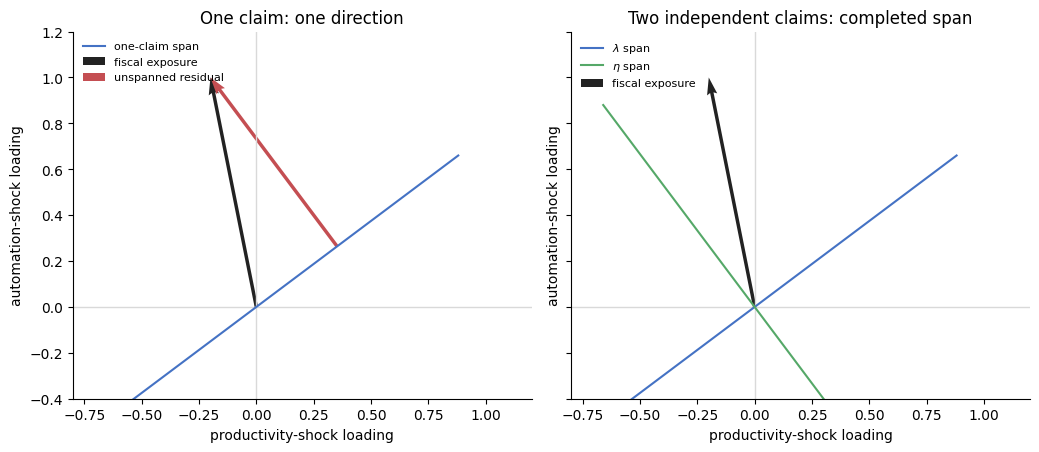

In [2]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(10.5, 4.4), sharex=True, sharey=True)
for ax in axes:
    ax.axhline(0, color="0.85", linewidth=1)
    ax.axvline(0, color="0.85", linewidth=1)
    ax.set_aspect("equal", adjustable="box")
    ax.set_xlim(-0.8, 1.2)
    ax.set_ylim(-0.4, 1.2)
    ax.set_xlabel("productivity-shock loading")
    ax.set_ylabel("automation-shock loading")
    ax.spines[["top", "right"]].set_visible(False)

scale = np.linspace(-1.1, 1.1, 50)
axes[0].plot(scale * lam[0], scale * lam[1], color="#4472C4", label="one-claim span")
axes[0].quiver(0, 0, *fiscal_exposure, angles="xy", scale_units="xy", scale=1,
               color="#222222", label="fiscal exposure")
axes[0].quiver(*marketed, *unspanned, angles="xy", scale_units="xy", scale=1,
               color="#C44E52", label="unspanned residual")
axes[0].set_title("One claim: one direction")
axes[0].legend(frameon=False, fontsize=8, loc="upper left")

axes[1].plot(scale * lam[0], scale * lam[1], color="#4472C4", label="$\\lambda$ span")
axes[1].plot(scale * eta[0], scale * eta[1], color="#55A868", label="$\\eta$ span")
axes[1].quiver(0, 0, *fiscal_exposure, angles="xy", scale_units="xy", scale=1,
               color="#222222", label="fiscal exposure")
axes[1].set_title("Two independent claims: completed span")
axes[1].legend(frameon=False, fontsize=8, loc="upper left")
plt.tight_layout()
plt.show()

## From geometry to the HJB

For any fixed smooth concave candidate value with $V_N>0$ and $V_{NN}<0$, adding the
orthogonal payoff direction contributes

$$
\mathcal P_2[V]-\mathcal P_1[V]
=-\frac{D_\eta[V]^2}{2\beta V_{NN}}\ge0.
$$

This is a local Hamiltonian statement. It does **not** by itself report the total
welfare gain: the value function and all policies change when the Bellman problem is
re-solved. Exact finite-risk welfare would require matched nonlinear solutions from the
same $(S_0,M_0)$.

## Economic interpretation

The traded claim is valuable only for the component of worker-relevant fiscal exposure
that covaries with its payoff. More of the same claim cannot insure an orthogonal
component. A second independent payoff can remove that financial spanning gap, but it
does not remove tax distortions, solvency constraints, or missing instruments outside
the two-shock diffusion space.

No consumption-equivalent welfare number, completed-span solution, or asset-versus-tax
ranking is available from current accepted evidence.

## Reproduce and trace

- Brownian implementation map: [`tai-public-finance` at `971cab1`](https://github.com/Nathan-Barnard/tai-public-finance/tree/971cab12986bce99c23a291fd62a5cde66ffa01a)
- Computation objects: CP003 and draft CS003
- Evidence status: exact rank/projection algebra plus an illustrative vector example
- Environment: repository `requirements-dev.txt`

Re-run with `jupyter nbconvert --to notebook --execute --inplace notebooks/02_brownian_valuation_and_payoff_span.ipynb`.